In [1]:
import Namelist as gv
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from scipy.io import loadmat, netcdf_file

import numpy as np




In [2]:
def get_landmask(filename):
    """
    This function reads landmask.nc. 
    read 0.25degree landmask.nc  -- updating to 0.125
    output:
        lon: longitude, 1D
        lat: latitude, 1D
        landmask:2D
  
    """
    f = netcdf_file(filename)
    lon = f.variables['lon'][:]
    lat = f.variables['lat'][:]
    landmask = f.variables['landmask'][:,:]
    f.close()

    return lon, lat, landmask


In [3]:
lm = xr.open_dataset(gv.landmaskfile)


In [4]:
lm.landmask

<xarray.DataArray 'landmask' (lat: 2160, lon: 4320)> Size: 37MB
[9331200 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 9kB -90.0 -89.92 -89.83 -89.75 ... 89.75 89.83 89.92
  * lon      (lon) float32 17kB 0.0 0.08333 0.1667 0.25 ... 359.8 359.8 359.9
Attributes:
    units:         sea=0, land>0
    actual_range:  [0. 3.]
    long_name:     land sea mask

In [5]:
llon, llat, lldmask = get_landmask(gv.landmaskfile)

# 2° — version on github
mask_2 = lldmask[::-24, ::24]
lon_2  = llon[::24]
lat_2  = llat[-12::-24]

# 0.75° 
mask_75 = lldmask[::-9, ::9]
lon_75  = llon[::9]
lat_75  = llat[-9::-9]

print('llat[:9]')
print(llat[:9])
print('llat[-9:]')
print(llat[-9:])

llat[:9]
[-90.       -89.916664 -89.833336 -89.75     -89.666664 -89.583336
 -89.5      -89.416664 -89.333336]
llat[-9:]
[89.25     89.333336 89.416664 89.5      89.583336 89.666664 89.75
 89.833336 89.916664]


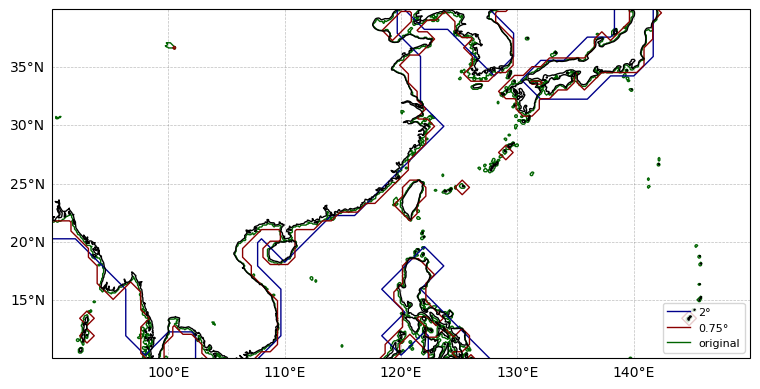

In [7]:
MyFigsize, MyFontsize = (8, 4), 8
londis, latdis = 30, 15
lon1, lon2 = 90, 150
lat1, lat2 = 10, 40

llon, llat, lldmask = get_landmask(gv.landmaskfile)

# flip mask rows to align with ascending llat
lldmask = lldmask[::-1, :]

## landmask import resolution (2160 x 4320) ~1/12º

# 2º 
mask_2 = lldmask[::-24, ::24]
lon_2  = llon[::24]
lat_2  = llat[::-24]

# 0.75º 
mask_75 = lldmask[::-9, ::9]
lon_75  = llon[::9]
lat_75  = llat[::-9]

mask_orig = lldmask
lon_orig  = llon
lat_orig  = llat


fig = plt.figure(figsize=MyFigsize)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
ax.coastlines(zorder=100)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--', x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

ax.contour(lon_orig, lat_orig, mask_orig, levels=[0.5], colors='darkgreen', linewidths=1, transform=ccrs.PlateCarree())
ax.contour(lon_2, lat_2, mask_2, levels=[0.5], colors='darkblue', linewidths=1, transform=ccrs.PlateCarree())
ax.contour(lon_75, lat_75, mask_75, levels=[0.5], colors='darkred', linewidths=1, transform=ccrs.PlateCarree())


from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='darkblue', linewidth=1, label='2°'),
    Line2D([0], [0], color='darkred',  linewidth=1, label='0.75°'),
    Line2D([0], [0], color='darkgreen',  linewidth=1, label='original'),
], loc = 'lower right',
fontsize=MyFontsize)

plt.tight_layout()
plt.show()

In [106]:
# MyFigsize, MyFontsize = (8, 4), 8
# londis, latdis = 30, 15
# lon1, lon2 = 90, 150
# lat1, lat2 = 10, 40

# fig = plt.figure(figsize=MyFigsize)
# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())  

# ax.coastlines(zorder=100)

# # ensure lat is ascending so contour draws right-side up
# lm_sorted = lm.sortby('lat')
# lm_sorted['landmask'] = lm_sorted['landmask'].isel(lat=slice(None, None, -1))
# lm_sorted['lat'] = lm_sorted['lat'].isel(lat=slice(None, None, -1))

# cs = ax.contour(
#     lm_sorted['lon'],
#     lm_sorted['lat'],
#     lm_sorted['landmask'],
#     levels=[0.5],
#     colors='darkblue',
#     linewidths=0.8,
#     transform=ccrs.PlateCarree()
# )

# gl = ax.gridlines(
#     draw_labels=True,
#     linewidth=0.5,
#     color='gray',
#     alpha=0.5,
#     linestyle='--',
#     x_inline=False,
#     y_inline=False,
# )
# gl.top_labels = False
# gl.right_labels = False


# # proxy artist for legend (contour doesn't support label= directly)
# from matplotlib.lines import Line2D
# legend_elements = [Line2D([0], [0], color='darkblue', linewidth=0.8, label='landmask file')]
# ax.legend(handles=legend_elements)

# ax.set_title('Landmask Edge')
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
# plt.tight_layout()
# plt.show()

In [ ]:
llon, llat,lldmask = gv.get_landmask(gv.landmaskfile)
ldldmask = lldmask[::-9,::9]
ldlon = llon[::9]                
ldlat = llat[::9]   
ldmask = lldmask[::-24,::24]
#lldmask = lldmask[::-1,:]


In [ ]:
llon, llat,lldmask = gv.get_landmask(gv.landmaskfile)
ldldmask = lldmask[::-9,::9]
ldlon = llon[::9]                
ldlat = llat[::9]   
ldmask = lldmask[::-24,::24]
#lldmask = lldmask[::-1,:]


In [28]:
len(ldlon)

480

In [29]:
len(ldlat)

240

In [32]:
ldldmask

array([[3., 3., 3., ..., 3., 3., 3.],
       [3., 3., 3., ..., 3., 3., 3.],
       [3., 3., 3., ..., 3., 3., 3.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(240, 480), dtype='>f4')

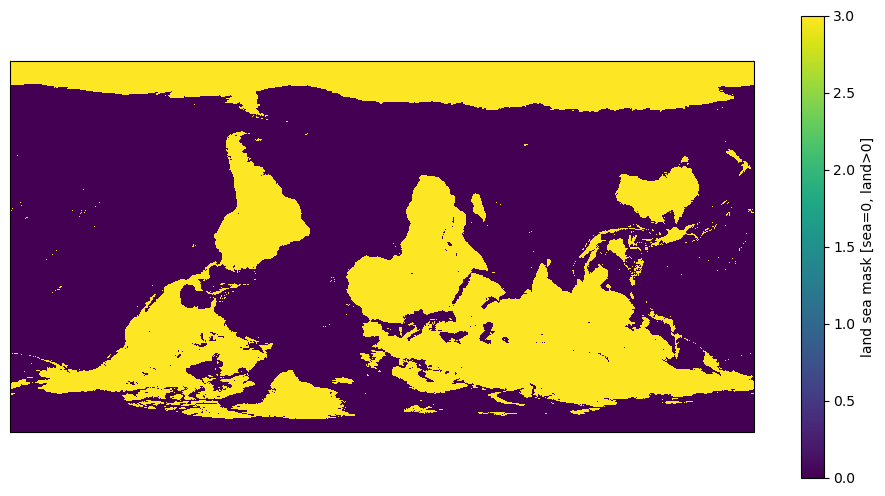

In [35]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# img = ax.pcolormesh(
#     ldlon, ldlat, ldldmask,
#     transform=ccrs.PlateCarree(),
#     cmap='viridis',
#     shading='auto'
# )


lm.landmask.plot(ax = ax)
